## Data Preprocessing

In this application, data preprocessing involves importing custom data, i.e., dataset that isn't part of the Keras, as a dataset, using this dataset (of type `BatchDataset`) in the application.

In [8]:
import os
import glob
import random
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.utils import image_dataset_from_directory

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Set Data Configuaration Parameters

In [17]:
@dataclass(frozen=True)
class DatasetConfig:
    NUM_CLASSES: int = 10
    IMG_HEIGHT: int = 224
    IMG_WIDTH: int = 224
    NUM_CHANNELS: int = 3
    BATCH_SIZE: int = 64
    DATA_ROOT: str = "./dataset"


@dataclass(frozen=True)
class TrainingConfig:
    EPOCHS: int = 21
    LEARNING_RATE: float = 0.001
    CHECKPOINT_DIR = "./saved_models"

In [18]:
datasetConfig = DatasetConfig()
trainingConfig = TrainingConfig()

In [19]:
# Set data paths
train_path = os.path.join(datasetConfig.DATA_ROOT, "train")
valid_path = os.path.join(datasetConfig.DATA_ROOT, "valid")

### Print class names

In [20]:
classNames = sorted([f for f in os.listdir(train_path) if not f.startswith(".")])

print("Classnames: ")
for i in range(len(classNames)):
    print(i, classNames[i])

Classnames: 
0 baseball
1 basketball
2 beachballs
3 billiard ball
4 bowling ball
5 brass
6 buckeyballs
7 cannon ball
8 cricket ball
9 eyeballs


### Data Visualisation

In [22]:
def getAllImagePaths(directoryName):
    print(directoryName)
    return glob.glob(f"{directoryName}/*/*", recursive=True)

In [15]:
def displayDatasetSamples(imagePaths):
    plt.figure(figsize=(18, 12))
    numRows = 5
    numCols = 8

    for i in range(numRows * numCols):
        plt.subplot(numRows, numCols, i + 1)

        # Generate a random index.
        idx = random.choice(list(range(0, len(imagePaths))))
        img = plt.imread(imagePaths[idx])
        label = imagePaths[idx].split("/")[-2]
        plt.imshow(img)
        plt.axis("off")
        plt.title(label)

    plt.show(block=False)

./dataset/train


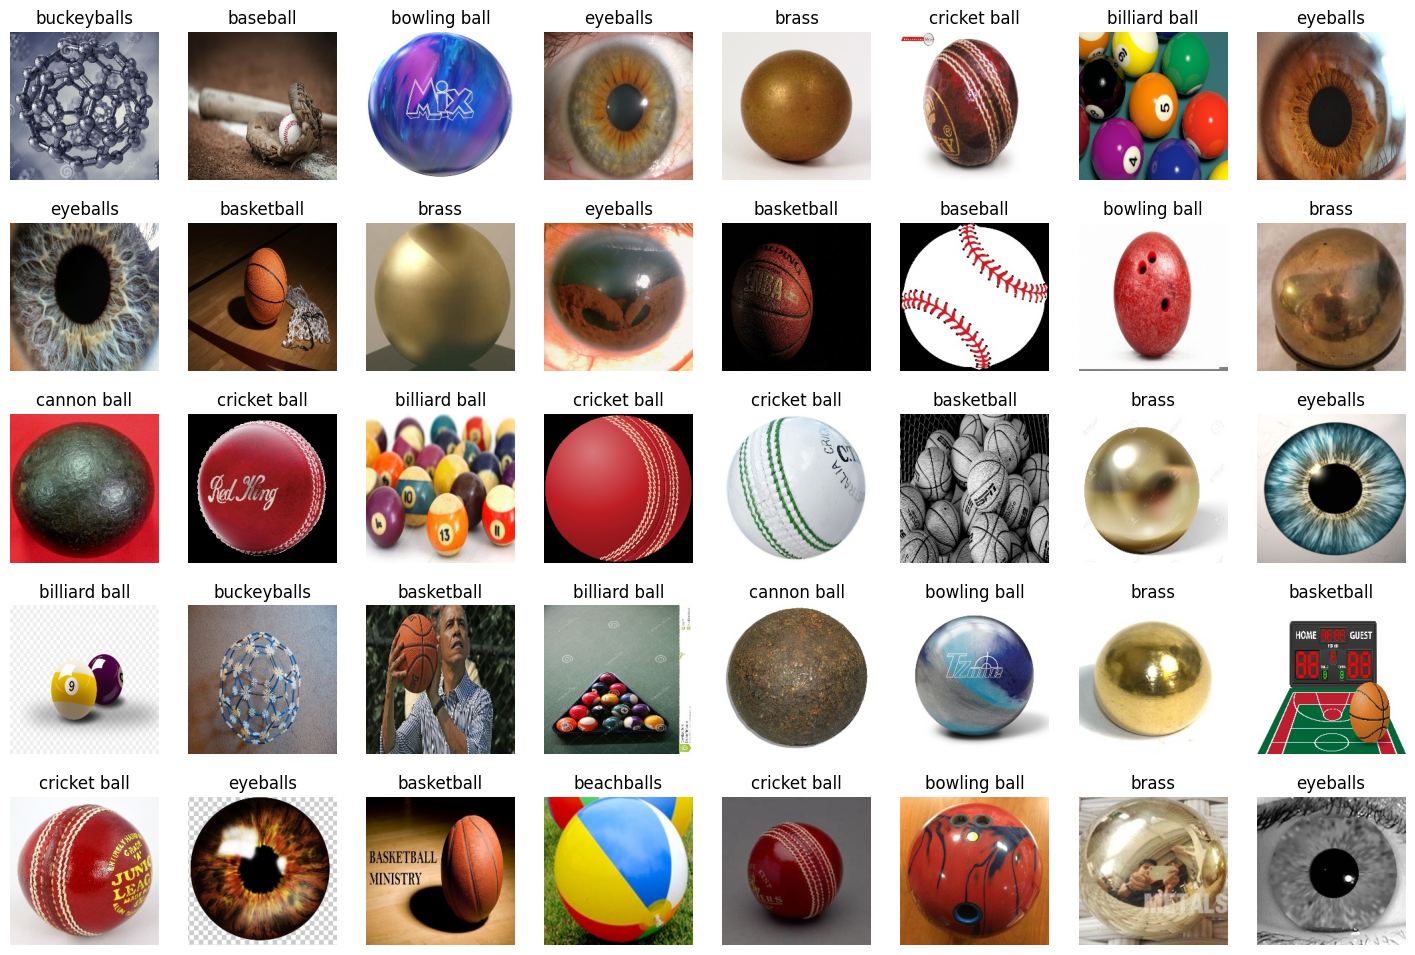

In [23]:
imagePaths = getAllImagePaths(train_path)

displayDatasetSamples(imagePaths)